# **Оценка эластичности спроса потребителей сервиса "Игры"**
Ссылка на датасет и описание признаков: https://dano.hse.ru/data2023

# **Предварительный анализ данных**

In [289]:
import pandas as pd
games = pd.read_csv('T_games_dataset.csv')
games

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0
3,1500364601,5-1VA0D94LX,2022-10-23,29688,Скидки,1204914,GTFO,1675.01,1.0,M,24,GRD,Самара,56000,283.0
4,1500288143,5-1QCUV9SY7,2022-07-03,28577,Экшн,1314503,Neon White,550.00,1.0,M,38,GRD,Санкт-Петербург,32000,1676.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88694,1500300796,5-355R05SQ3,2022-07-23,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,18,SCH,Москва,170486,0.0
88695,1500302138,5-2IKJ0HXNU,2022-07-25,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,19,UGR,Самара,38000,0.0
88696,1500351510,5-8EVSLK13,2022-10-05,28577,Экшн,1406123,Dome Keeper - Deluxe Edition,561.60,1.0,M,33,SCH,Краснодар,230000,0.0
88697,1500476540,5-122LQCE7M,2023-02-13,28574,Ролевые (RPG),848895,Gothic Universe Edition,59.80,1.0,M,37,GRD,Москва,170000,0.0


 **Анализ содержания датафрейма и удаление выбросов**

In [290]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88699 entries, 0 to 88698
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      88699 non-null  int64  
 1   client_id               88699 non-null  object 
 2   order_day               88699 non-null  object 
 3   category_id             88699 non-null  int64  
 4   category_name           88699 non-null  object 
 5   good_id                 88699 non-null  int64  
 6   good_name               88699 non-null  object 
 7   good_price              88699 non-null  float64
 8   good_cnt                88699 non-null  float64
 9   gender_cd               88699 non-null  object 
 10  age                     88699 non-null  int64  
 11  education_level         88699 non-null  object 
 12  city_nm                 88699 non-null  object 
 13  monthly_income_amt      88699 non-null  int64  
 14  steam_popularity_score  88699 non-null

In [291]:
iqr1 = games['good_price'].quantile(0.75) - games['good_price'].quantile(0.25)
bt1 = games['good_price'].quantile(0.25) - 1.5*iqr1
top1 = games['good_price'].quantile(0.75) + 1.5*iqr1

iqr2 = games['age'].quantile(0.75) - games['age'].quantile(0.25)
bt2 = games['age'].quantile(0.25) - 1.5*iqr2
top2 = games['age'].quantile(0.75) + 1.5*iqr2

iqr3 = games['monthly_income_amt'].quantile(0.75) - games['monthly_income_amt'].quantile(0.25)
bt3 = games['monthly_income_amt'].quantile(0.25) - 1.5*iqr3
top3 = games['monthly_income_amt'].quantile(0.75) + 1.5*iqr3

games_cln = games[(games['good_price'] >= bt1) & (games['good_price'] <= top1) & (games['age'] >= bt2) & (games['age'] <= top2) 
& (games['monthly_income_amt'] >= bt3) & (games['monthly_income_amt'] <= top3)]

games_cln #датафрейм без выбросов

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0
4,1500288143,5-1QCUV9SY7,2022-07-03,28577,Экшн,1314503,Neon White,550.00,1.0,M,38,GRD,Санкт-Петербург,32000,1676.0
5,1500272141,5-MDJBUKHR,2022-06-07,28565,Симуляторы,1123552,The Dweller,13.00,1.0,M,26,UGR,Москва,92000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88694,1500300796,5-355R05SQ3,2022-07-23,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,18,SCH,Москва,170486,0.0
88695,1500302138,5-2IKJ0HXNU,2022-07-25,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,19,UGR,Самара,38000,0.0
88696,1500351510,5-8EVSLK13,2022-10-05,28577,Экшн,1406123,Dome Keeper - Deluxe Edition,561.60,1.0,M,33,SCH,Краснодар,230000,0.0
88697,1500476540,5-122LQCE7M,2023-02-13,28574,Ролевые (RPG),848895,Gothic Universe Edition,59.80,1.0,M,37,GRD,Москва,170000,0.0


**Профиль покупаемых товаров сервиса**

In [292]:
games_cln['category_name'].value_counts()

category_name
Экшн                       13680
Приключения                 9526
Инди                        9410
Стратегии                   9128
Симуляторы                  7295
Скидки                      6895
Ролевые (RPG)               6698
Бестселлеры                 2601
Казуальные игры             2418
Шутеры                      1871
Хоррор                      1453
Гонки                       1433
Файтинги                     573
Аркады                       514
Anime                        463
VR                           410
Спорт                        325
Другое                       210
Новинки                      205
Xbox подписка                175
Классика от Deep Silver      151
Для детей                     92
Онлайн (MMO)                  17
Предзаказы                     4
Карты оплаты                   3
Name: count, dtype: int64

Выделим самые популярные категории игр по количеству приобретений:
* Экшн
* Приключения
* Инди
* Стратегии
* Симуляторы
* Ролевые (RPG)
  
Категория Скидки вероятнее всего включает в себя другие категории игр, продаваемые по сниженным ценам.
Проверим это, сравнив названия игр в категории Скидки и других категориях.

In [293]:
discounted_goods = games_cln[games_cln['category_name'] == 'Скидки']['good_name']
games_cln[(games_cln['good_name'].isin(discounted_goods)) & (games_cln['category_name'] != 'Скидки')].shape

(18385, 15)

Действительно, категория Скидки включает в себя товары из других категорий, поэтому не будем включать ее в список самых популярных. 
Зафиксируем наблюдение о наличии повышенного интереса потребителей к играм, продающимся по скидке.

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\User\AppData\Local\Temp\ipykernel_23004\846104584.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_cln['grouped_category'] = games_cln['category_name'].apply(group_categories)


([<matplotlib.patches.Wedge at 0x24a3d7eac50>,
 [Text(0.7473146052493495, 0.8071684339597338, 'Другое'),
  Text(-0.6620431270487759, 0.8784639423035407, 'Экшн'),
  Text(-1.0991199991113776, -0.043991221322047504, 'Приключения'),
  Text(-0.7444570412879205, -0.8098047379935707, 'Инди'),
  Text(0.03023103262064667, -1.099584505468629, 'Стратегии'),
  Text(0.717353419974274, -0.8339089104040159, 'Симуляторы'),
  Text(1.057608892574239, -0.3024292154337804, 'Ролевые (RPG)')],
 [Text(0.4076261483178269, 0.4402736912507638, '26.23%'),
  Text(-0.3611144329356959, 0.4791621503473858, '18.11%'),
  Text(-0.5995199995152968, -0.023995211630207725, '12.61%'),
  Text(-0.4060674770661384, -0.44171167526922034, '12.46%'),
  Text(0.016489654156716365, -0.5997733666192522, '12.08%'),
  Text(0.39128368362233124, -0.45485940567491767, '9.66%'),
  Text(0.5768775777677667, -0.16496139023660744, '8.87%')])

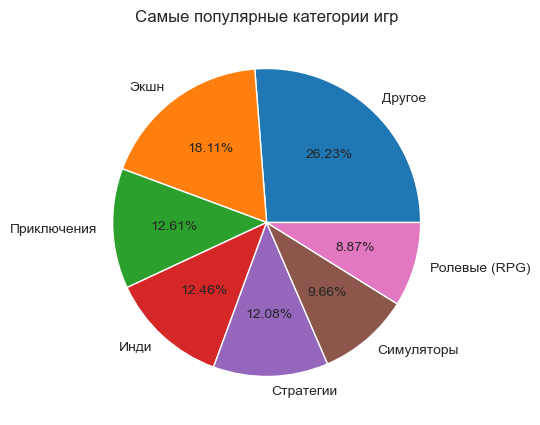

In [295]:
top_categories = ['Экшн', 'Приключения', 'Инди', 'Стратегии', 'Симуляторы', 'Ролевые (RPG)']
def group_categories(category):
    if category in top_categories:
        return category
    else:
        return 'Другое'
games_cln['grouped_category'] = games_cln['category_name'].apply(group_categories)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Самые популярные категории игр')
ax.pie(games_cln['grouped_category'].value_counts(), labels = games_cln['grouped_category'].value_counts().index, autopct = '%.2f%%')

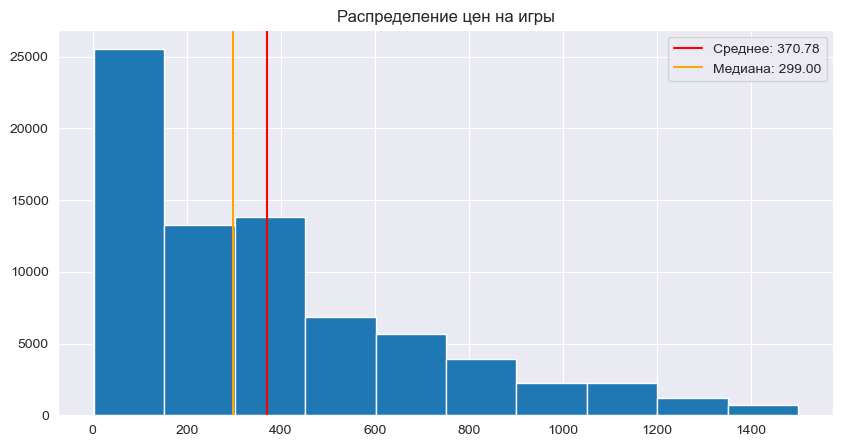

In [296]:
sns.set_style('darkgrid')
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Распределение цен на игры')
ax.hist(games_cln['good_price']);
ax.axvline(games_cln['good_price'].mean(), color = 'red', label = f'Среднее: {games_cln["good_price"].mean():.2f}')
ax.axvline(games_cln['good_price'].median(), color = 'orange', label = f'Медиана: {games_cln["good_price"].median():.2f}')
ax.legend()

Средний ценовой диапазон покупаемых товаров: 300-400 руб. Имеется значительный скос в распределении в сторону более дорогих товаров, что говорит о наличии спроса на преимиальные товары.

**Профиль клиентов сервиса**

In [297]:
games_cln_unique = games_cln.drop_duplicates(subset=['client_id'], keep='first')
games_cln_unique #для анализа нужны только уникальные пользователи

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,grouped_category
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0,Другое
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0,Ролевые (RPG)
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0,Другое
4,1500288143,5-1QCUV9SY7,2022-07-03,28577,Экшн,1314503,Neon White,550.00,1.0,M,38,GRD,Санкт-Петербург,32000,1676.0,Экшн
5,1500272141,5-MDJBUKHR,2022-06-07,28565,Симуляторы,1123552,The Dweller,13.00,1.0,M,26,UGR,Москва,92000,0.0,Симуляторы
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88688,1500518896,5-3C8UI2RD1,2023-03-17,28574,Ролевые (RPG),1127102,Septerra Core,11.88,1.0,M,38,SCH,Новосибирск,38000,4072.0,Ролевые (RPG)
88691,1500525851,5-VAPT0BRT,2023-03-26,28579,Гонки,880568,Cyberline Racing,5.80,1.0,M,37,GRD,Санкт-Петербург,101600,2444.0,Другое
88693,1500562469,5-3FSSUW4LD,2023-05-12,28579,Гонки,880568,Cyberline Racing,5.80,1.0,M,15,GRD,Новосибирск,-85182,2444.0,Другое
88694,1500300796,5-355R05SQ3,2022-07-23,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,18,SCH,Москва,170486,0.0,Экшн


([<matplotlib.patches.Wedge at 0x24a3d805690>,
 [Text(-1.0338884076298358, 0.37559920203408637, 'M'),
  Text(1.033888434004435, -0.3755991294343708, 'F')],
 [Text(-0.5639391314344558, 0.20487229201859253, '88.91%'),
  Text(0.5639391458206009, -0.2048722524187477, '11.09%')])

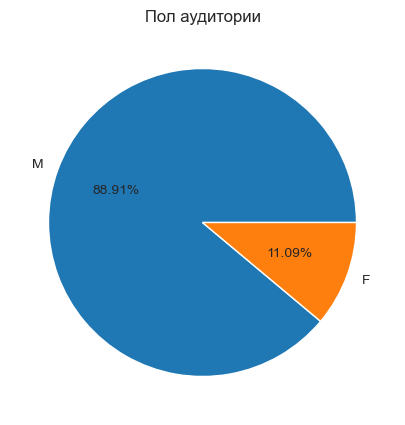

In [298]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Пол аудитории')
ax.pie(games_cln_unique['gender_cd'].value_counts(), labels = games_cln_unique['gender_cd'].value_counts().index, autopct = '%.2f%%')

Преобладающее большинство клиентов сервиса - мужчины.

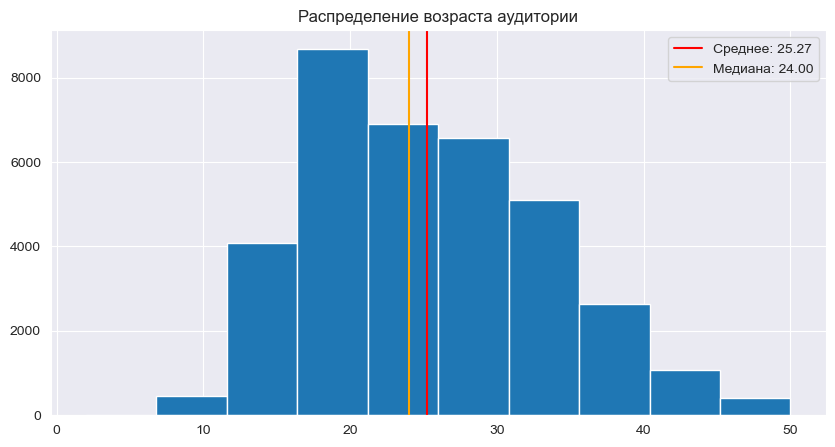

In [299]:
sns.set_style('darkgrid')
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Распределение возраста аудитории')
ax.hist(games_cln_unique['age']);
ax.axvline(games_cln_unique['age'].mean(), color = 'red', label = f'Среднее: {games_cln_unique["age"].mean():.2f}')
ax.axvline(games_cln_unique['age'].median(), color = 'orange', label = f'Медиана: {games_cln_unique["age"].median():.2f}')
ax.legend()

Основные пользователи сервиса - молодежь в возрасте около 25 лет. Небольшой скос в распределении говорит о наличии интереса к сервису и у более старшей аудитории.

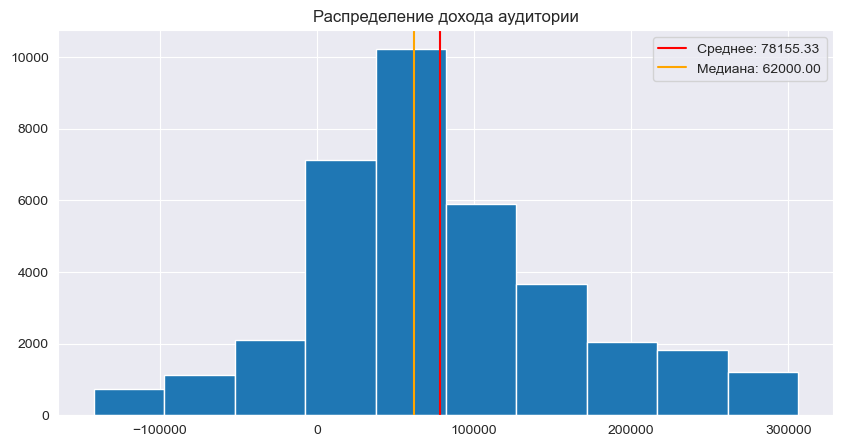

In [300]:
sns.set_style('darkgrid')
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Распределение дохода аудитории')
ax.hist(games_cln_unique['monthly_income_amt']);
ax.axvline(games_cln_unique['monthly_income_amt'].mean(), color = 'red', label = f'Среднее: {games_cln_unique["monthly_income_amt"].mean():.2f}')
ax.axvline(games_cln_unique['monthly_income_amt'].median(), color = 'orange', label = f'Медиана: {games_cln_unique["monthly_income_amt"].median():.2f}')
ax.legend()

Гистограмма показала, что датафрейм содержит отрицательные значения месячного дохода. Возможно это ошибочные данные. Для анализа дохода удалим из датафрейма пользователей с отрицательным значеним дохода.

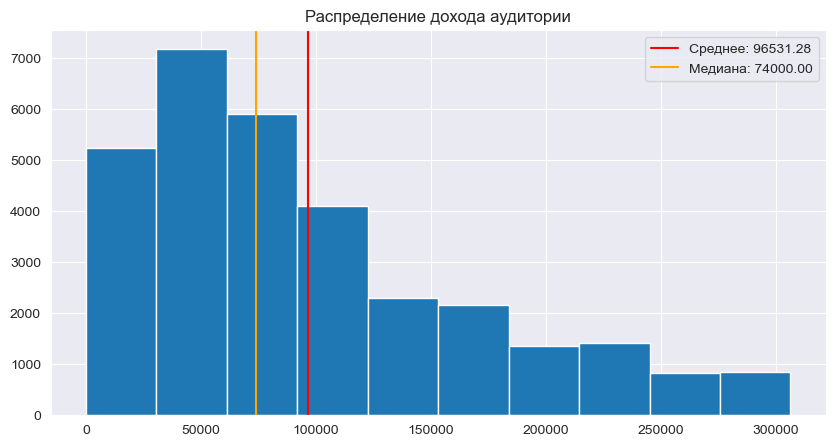

In [301]:
games_norm_income = games_cln_unique[games_cln_unique['monthly_income_amt'] >=0] #датафрейм с уникальными пользователями, имеющими положительный доход

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Распределение дохода аудитории')
ax.hist(games_norm_income['monthly_income_amt']);
ax.axvline(games_norm_income['monthly_income_amt'].mean(), color = 'red', label = f'Среднее: {games_norm_income["monthly_income_amt"].mean():.2f}')
ax.axvline(games_norm_income['monthly_income_amt'].median(), color = 'orange', label = f'Медиана: {games_norm_income["monthly_income_amt"].median():.2f}')
ax.legend()

Распределение имеет правостороннюю ассиметрию, что говорит о наличии небольшого количества аудитории, чей доход значительно превышает средний.

In [302]:
games_cln_unique['education_level'].value_counts()

education_level
GRD    15121
SCH    12065
UGR     8108
PGR      540
ACD       84
Name: count, dtype: int64

Преобладающие уровни образования аудитории:
* GRD - высшее
* SCH - начальное, среднее
* UGR - неполное высшее

C:\Users\User\AppData\Local\Temp\ipykernel_23004\1005392238.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_cln_unique['grouped_educations'] = games_cln_unique['education_level'].apply(group_education)


([<matplotlib.patches.Wedge at 0x24a48d305d0>,
 [Text(0.27025496100582624, 1.0662843223323408, 'Высшее'),
  Text(-0.9326704862490618, -0.5832030213227113, 'Начальное, среднее'),
  Text(0.7517861335131503, -0.8030053607899189, 'Неполное высшее'),
  Text(1.0983620480485619, -0.06000676134044039, 'Другое')],
 [Text(0.14741179691226886, 0.581609630363095, '42.10%'),
  Text(-0.5087293561358518, -0.318110738903297, '33.59%'),
  Text(0.41006516373444557, -0.43800292406722846, '22.57%'),
  Text(0.5991065716628519, -0.032730960731149304, '1.74%')])

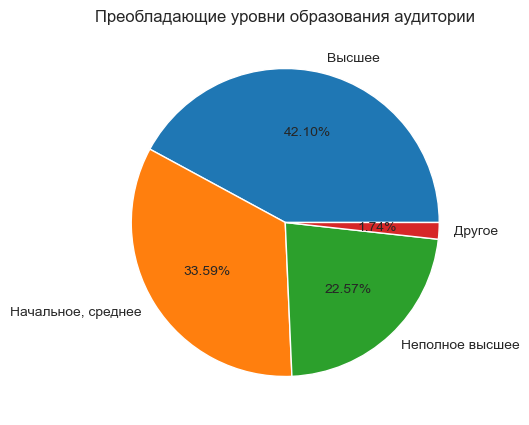

In [303]:
def group_education(level):
    if level == 'GRD':
        return 'Высшее'
    elif level == 'SCH':
        return 'Начальное, среднее'
    elif level == 'UGR':
        return 'Неполное высшее'
    else:
        return 'Другое'
games_cln_unique['grouped_educations'] = games_cln_unique['education_level'].apply(group_education)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Преобладающие уровни образования аудитории')
ax.pie(games_cln_unique['grouped_educations'].value_counts(), labels = games_cln_unique['grouped_educations'].value_counts().index, autopct = '%.2f%%')

Наибольшая доля аудитории имеет высшее образование. Остальная часть, в основном, представлена пользователями с более низким уровнем образования. Незначительная доля пользователей имеет ученую степень или два высших образования, что согласуется с преобладанием молодой аудитории, которая в силу возраста еще не могла получить такую высокую квалификацию.

In [304]:
games_cln_unique['city_nm'].value_counts()

city_nm
Москва             14666
Санкт-Петербург     7469
Екатеринбург        1845
Новосибирск         1812
Казань              1115
Краснодар           1061
Нижний Новгород     1013
Самара               963
Ростов-на-Дону       919
Челябинск            854
Красноярск           820
Уфа                  771
Пермь                765
Воронеж              715
Омск                 648
Волгоград            482
Name: count, dtype: int64

Преобладающие места жительства аудитории:
* Москва
* Санкт-Петербург

C:\Users\User\AppData\Local\Temp\ipykernel_23004\552645854.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_cln_unique['grouped_city'] = games_cln_unique['city_nm'].apply(group_city)


([<matplotlib.patches.Wedge at 0x24a434c8dd0>,
 [Text(0.31246458086718937, 1.0546875772964674, 'Москва'),
  Text(-0.889160321515993, -0.6476063021941464, 'Другое'),
  Text(0.8735031173539076, -0.6685748304961874, 'Санкт-Петербург')],
 [Text(0.1704352259275578, 0.5752841330708003, '40.83%'),
  Text(-0.4849965390087234, -0.3532398011968071, '38.37%'),
  Text(0.47645624582940405, -0.36467718027064766, '20.79%')])

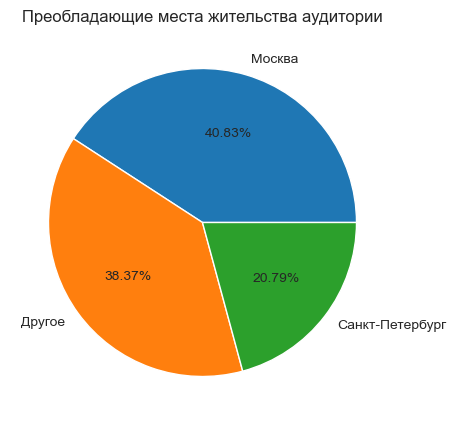

In [305]:
def group_city(nm):
    if nm == 'Москва' or nm == 'Санкт-Петербург':
        return nm
    else:
        return 'Другое'
games_cln_unique['grouped_city'] = games_cln_unique['city_nm'].apply(group_city)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Преобладающие места жительства аудитории')
ax.pie(games_cln_unique['grouped_city'].value_counts(), labels = games_cln_unique['grouped_city'].value_counts().index, autopct = '%.2f%%')

Более 60% аудитории сервиса сосредоточено в Москве и Санкт-Петербурге. Примечательно, что москвоская аудитория превышает суммарное количество пользователей из других городов, помимо Москвы и Санкт-Петербурга. Это может указывать на недостаточное проникновение сервиса в регионах.


# **Задание 1**

**Отличительная особенность аудитории сервиса** - преобладание молодых людей мужского пола, преимущественно из Москвы и Санкт-Петербурга.

## **Выделим заядлых покупателей игр**

In [306]:
games_cln['good_cnt'].unique()

array([1.])

Удостовелились, что каждая игра была заказана в единственном экземпляре.

Найдем, сколько покупок совершил каждый игрок (сгруппируем данные по id клиентов)

In [307]:
purchases = games_cln.groupby('client_id').size().reset_index(name='count')
purchases

,client_id,count
0,1-11B0XBL,1
1,1-15GSF3N,1
2,1-17GCAKP,1
3,1-1AJFCHX,11
4,1-1BFARRI,1
...,...,...
35913,7-3L9WII18P,1
35914,7-3LB1WGM5N,1
35915,7-3LD4MQHZH,1
35916,7-3LDU97X2M,1


Будем считать заядлыми игроков, количество покупок которых лежит выше девятого дециля (10% игроков, совершивших больше всего покупок).

In [308]:
compulsive_gamers = purchases[purchases['count'] > purchases['count'].quantile(0.9)]
(compulsive_gamers['client_id'].nunique()/games_cln_unique.shape[0])*100

7.734283646082744

После сортировки игроков по этому методу удалось выделить 7,7% заядлых игроков.

In [309]:
compulsive_gamers_df = games_cln_unique[games_cln_unique['client_id'].isin(compulsive_gamers['client_id'])] 
#датафрейм с уникальными данными заядлых игроков
other_gamers_df = games_cln_unique[~games_cln_unique['client_id'].isin(compulsive_gamers['client_id'])] 
#датафрейм с уникальными данными остальных игроков

## **Сравним заядлых игроков с остальной аудиторией**

([<matplotlib.patches.Wedge at 0x24a48172f50>,
 [Text(-1.033491368724977, 0.37669031149071797, 'M'),
  Text(1.0334913599079034, -0.37669033568132904, 'F')],
 [Text(-0.5637225647590782, 0.20546744263130068, '88.87%'),
  Text(0.5637225599497655, -0.20546745582617945, '11.13%')])

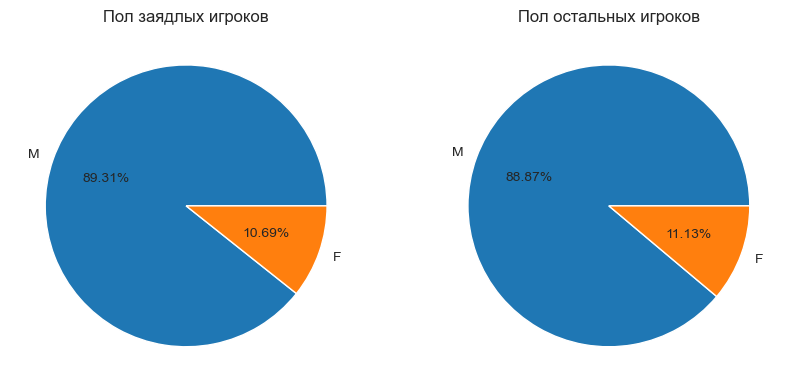

In [310]:
fig, ax = plt.subplots(1,2, figsize=(10, 5))
ax[0].set_title('Пол заядлых игроков')
ax[0].pie(compulsive_gamers_df['gender_cd'].value_counts(), labels = compulsive_gamers_df['gender_cd'].value_counts().index, autopct = '%.2f%%')
ax[1].set_title('Пол остальных игроков')
ax[1].pie(other_gamers_df['gender_cd'].value_counts(), labels = other_gamers_df['gender_cd'].value_counts().index, autopct = '%.2f%%')

Гендерные различия между заядлыми и остальными игроками незначительны. В обеих группах преобладают мужчины.

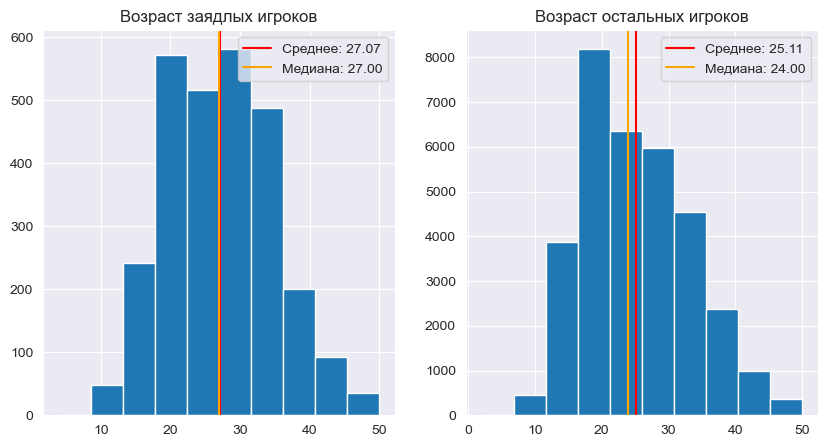

In [311]:
sns.set_style('darkgrid')
fig, ax = plt.subplots(1,2, figsize=(10, 5))

ax[0].set_title('Возраст заядлых игроков')
ax[0].hist(compulsive_gamers_df['age'])
ax[0].axvline(compulsive_gamers_df['age'].mean(), color = 'red', label = f'Среднее: {compulsive_gamers_df["age"].mean():.2f}')
ax[0].axvline(compulsive_gamers_df['age'].median(), color = 'orange', label = f'Медиана: {compulsive_gamers_df["age"].median():.2f}')
ax[0].legend()

ax[1].set_title('Возраст остальных игроков')
ax[1].hist(other_gamers_df['age'])
ax[1].axvline(other_gamers_df['age'].mean(), color = 'red', label = f'Среднее: {other_gamers_df["age"].mean():.2f}')
ax[1].axvline(other_gamers_df['age'].median(), color = 'orange', label = f'Медиана: {other_gamers_df["age"].median():.2f}')
ax[1].legend()

Возраст заядлых игроков достаточно однороден: большинство аудитории - молодые люди в возрасте 27 лет. Группа остальных игроков представлена более широким возрастным диапазоном.

([<matplotlib.patches.Wedge at 0x24a482f0e50>,
 [Text(0.275255384772272, 1.0650044474807927, 'Высшее'),
  Text(-0.9359646934025884, -0.577901455876172, 'Начальное, среднее'),
  Text(0.7510535782894285, -0.8036905639228604, 'Неполное высшее'),
  Text(1.0983662463946617, -0.05992986551713189, 'Другое')],
 [Text(0.1501393007848756, 0.580911516807705, '41.95%'),
  Text(-0.5105261964014117, -0.3152189759324574, '33.71%'),
  Text(0.4096655881578701, -0.4383766712306511, '22.61%'),
  Text(0.5991088616698155, -0.032689017554799214, '1.74%')])

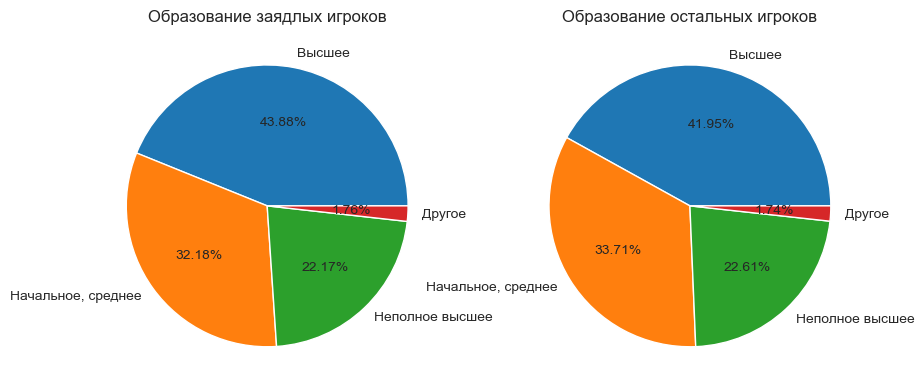

In [312]:
fig, ax = plt.subplots(1,2, figsize=(10, 5))

ax[0].set_title('Образование заядлых игроков')
ax[0].pie(compulsive_gamers_df['grouped_educations'].value_counts(), labels = compulsive_gamers_df['grouped_educations'].value_counts().index, 
          autopct = '%.2f%%')
ax[1].set_title('Образование остальных игроков')
ax[1].pie(other_gamers_df['grouped_educations'].value_counts(), labels = other_gamers_df['grouped_educations'].value_counts().index, 
          autopct = '%.2f%%')

* Доля аудитории с высшим образованием больше в группе заядлых игроков, чем в группе остальных игроков. 
* Доля аудитории с начальным и среднем образованием больше в группе обычных игроков, чем в группе заядлых игроков.

([<matplotlib.patches.Wedge at 0x24a4e094e50>,
 [Text(0.3142327978041092, 1.0541621074503684, 'Москва'),
  Text(-0.8888141604848494, -0.6480813128933843, 'Другое'),
  Text(0.8749793533158483, -0.6666416813183675, 'Санкт-Петербург')],
 [Text(0.17139970789315043, 0.5749975131547463, '40.78%'),
  Text(-0.4848077239008269, -0.35349889794184597, '38.50%'),
  Text(0.47726146544500814, -0.36362273526456407, '20.72%')])

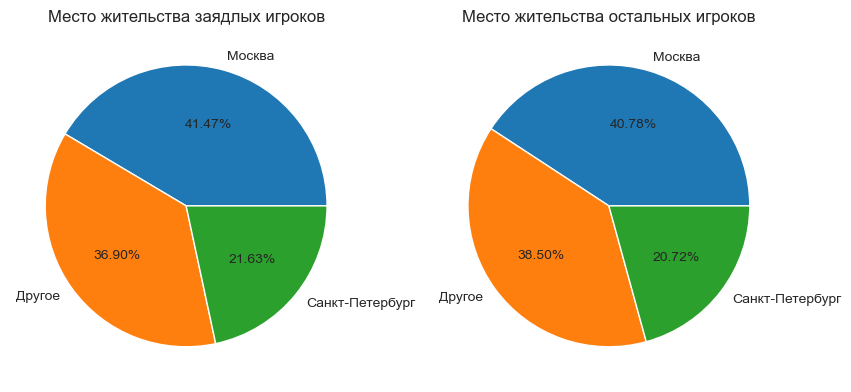

In [313]:
fig, ax = plt.subplots(1,2, figsize=(10, 5))

ax[0].set_title('Место жительства заядлых игроков')
ax[0].pie(compulsive_gamers_df['grouped_city'].value_counts(), labels = compulsive_gamers_df['grouped_city'].value_counts().index, autopct = '%.2f%%')
ax[1].set_title('Место жительства остальных игроков')
ax[1].pie(other_gamers_df['grouped_city'].value_counts(), labels = other_gamers_df['grouped_city'].value_counts().index, autopct = '%.2f%%')

* Доля аудитории, живущей в Москве и Санкт-Петербурге, больше в группе заядлых игроков, чем в группе остальных игроков.
* Доля аудитории, живущей в других городах, больше в группе остальных игроков, чем в группе заядлых игроков.

## **Проанализируем особенности покупателей различных категорий игр**

Исключим из анализа категории Предзаказы, Карты оплаты и Онлайн (MMO), так как по ним совершено меньше всего покупок.

In [314]:
categories_to_exclude = ['Карты оплаты', 'Онлайн (MMO)', 'Предзаказы']
games_cat_analysis = games_cln_unique[~games_cln_unique['category_name'].isin(categories_to_exclude)]

**Сегментирование по полу**

In [315]:
pivot_sex = pd.pivot_table(games_cat_analysis, index='category_name', columns = 'gender_cd', aggfunc='size', fill_value=0)
pivot_sex                             

gender_cd,F,M
category_name,,
Anime,19,193
VR,33,251
Xbox подписка,16,97
Аркады,28,216
Бестселлеры,119,1473
Гонки,65,733
Для детей,19,24
Другое,12,119
Инди,676,3946


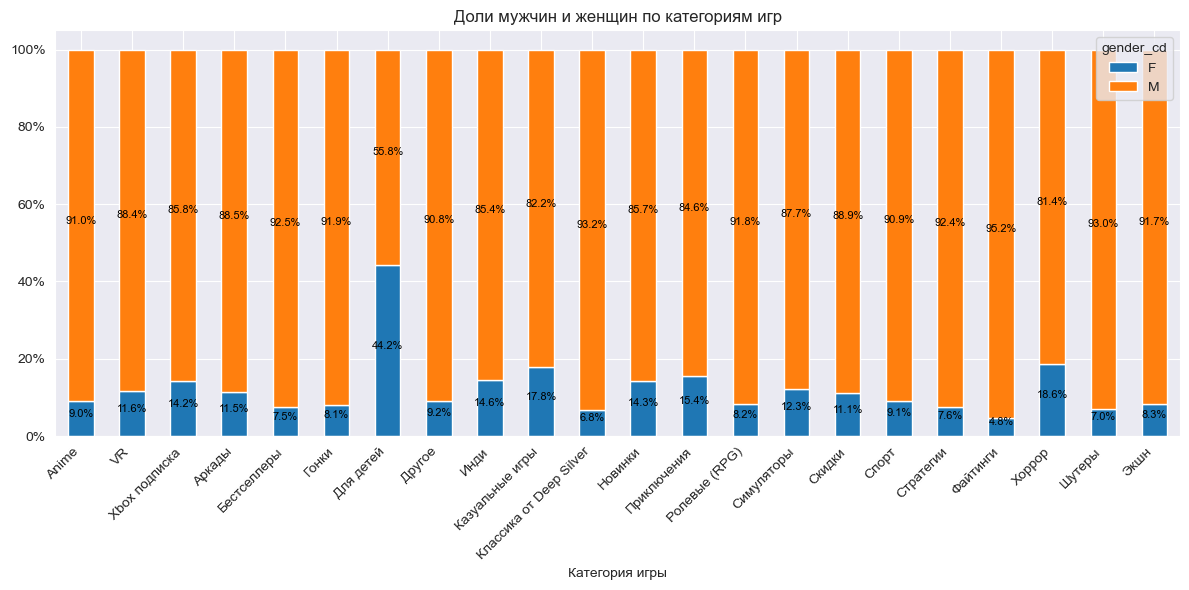

In [316]:
pivot_sex_norm = pivot_sex.div(pivot_sex.sum(axis=1), axis=0) 
pivot_sex_norm = pivot_sex_norm * 100

from matplotlib.ticker import PercentFormatter
ax = pivot_sex_norm.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Доли мужчин и женщин по категориям игр')
plt.xlabel('Категория игры')
plt.xticks(rotation=45, ha='right')

for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            x = rect.get_x() + rect.get_width() / 2
            y = rect.get_y() + height / 2
            label_text = f'{height:.1f}%' 
            ax.text(x, y, label_text, ha='center', va='bottom', color='black', fontsize=8)
            
ax.yaxis.set_major_formatter(PercentFormatter())
            
plt.tight_layout()
plt.show()

Учитывая, что в выборке мужчин в девять раз больше, чем женщин, будем считать будем считать, что сильное отклонение от базового отношения женщин к мужчинам 1:9 в рамках категорий свидетельствует о повышенном интересе представителей соответствующего пола к данной категории.

Таким образом,
* наиболее выраженная категория игр среди женской аудитории: Для детей
* наиболее выраженная категория игр среди мужской аудитории: Файтинги

**Сегментирование по возрасту**

Выделим следующие возрастные категории:
1. до 18 лет
2. 18-30 лет
3. 30+ лет

In [317]:
def age_segmentation(age):
    if age < 18:
        return 'до 18 лет'
    elif age >=18 and age<30:
        return '18-30 лет'
    else:
        return '30+ лет'

games_cat_analysis['age_segmentation'] = games_cat_analysis['age'].apply(age_segmentation)

pivot_age = pd.pivot_table(games_cat_analysis, index='category_name', columns = 'age_segmentation', aggfunc='size', fill_value=0)

new_order = ['до 18 лет', '18-30 лет', '30+ лет'] 
pivot_age = pivot_age[new_order]
pivot_age

C:\Users\User\AppData\Local\Temp\ipykernel_23004\312404415.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_cat_analysis['age_segmentation'] = games_cat_analysis['age'].apply(age_segmentation)


age_segmentation,до 18 лет,18-30 лет,30+ лет
category_name,,,
Anime,33,137,42
VR,64,181,39
Xbox подписка,12,56,45
Аркады,49,117,78
Бестселлеры,293,939,360
Гонки,242,342,214
Для детей,1,21,21
Другое,21,52,58
Инди,950,2495,1177


In [318]:
total_1 = games_cat_analysis[games_cat_analysis['age_segmentation'] == 'до 18 лет'].shape[0]
total_2 = games_cat_analysis[games_cat_analysis['age_segmentation'] == '18-30 лет'].shape[0]
total_3 = games_cat_analysis[games_cat_analysis['age_segmentation'] == '30+ лет'].shape[0]
total = games_cat_analysis.shape[0]

print(f'Доля первой возрастной категории до 18 лет: {round((total_1/total)*100, 2)}%')
print(f'Доля второй возрастной категории 18-30 лет: {round((total_2/total)*100, 2)}%')
print(f'Доля третьей возрастной категории 30+ лет: {round((total_3/total)*100, 2)}%')

Доля первой возрастной категории до 18 лет: 16.61%
Доля второй возрастной категории 18-30 лет: 54.67%
Доля третьей возрастной категории 30+ лет: 28.72%


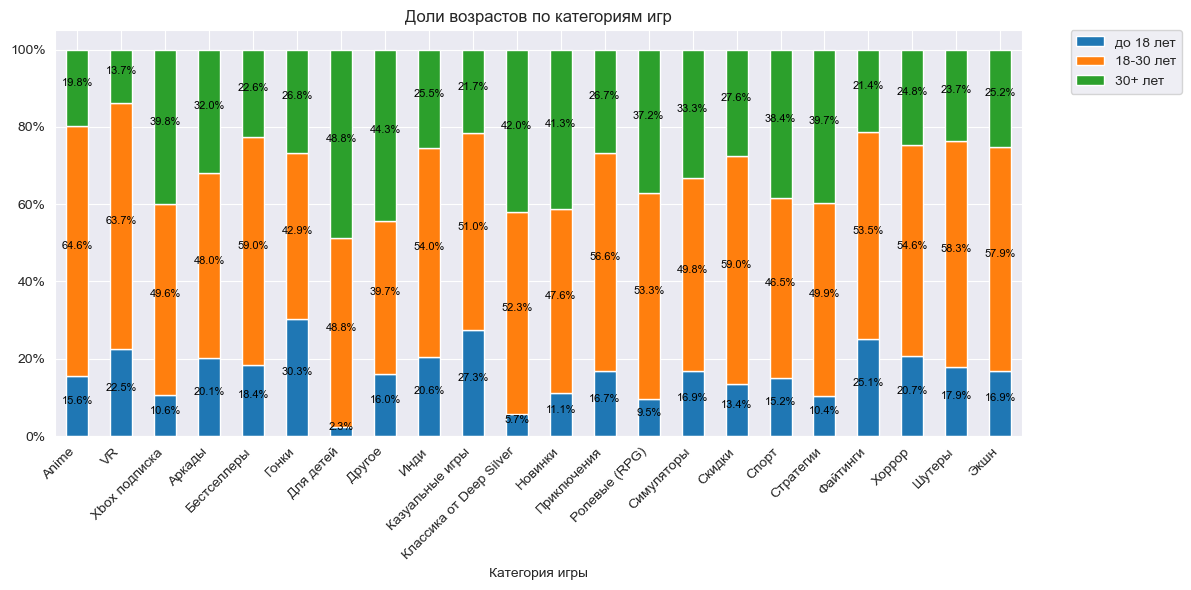

In [319]:
pivot_age_norm = pivot_age.div(pivot_age.sum(axis=1), axis=0) 
pivot_age_norm = pivot_age_norm*100
ax = pivot_age_norm.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Доли возрастов по категориям игр')
plt.xlabel('Категория игры')
plt.xticks(rotation=45, ha='right')
for i, bar in enumerate(ax.containers):
    for rect in bar:
        height = rect.get_height()
        if height > 0:
            x = rect.get_x() + rect.get_width() / 2
            y = rect.get_y() + height / 2
            label_text = f'{height:.1f}%' 
            ax.text(x, y, label_text, ha='center', va='bottom', color='black', fontsize=8)
            
ax.yaxis.set_major_formatter(PercentFormatter())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

* Наиболее выраженная категория игр для аудитории до 18 лет: Гонки
* Наиболее выраженные категории игр для аудитории 18-30 лет: Anime и VR
* Наиболее выраженная категория игр для аудитории до 18 лет: Для детей

# **Задание 2**

## **Анализ цен**

**Цены по категориям игр**

In [320]:
prices_by_cat = games_cln.groupby('category_name')['good_price'].describe()
prices_by_cat.sort_values(by = 'mean')

,count,mean,std,min,25%,50%,75%,max
category_name,,,,,,,,
VR,410.0,45.960439,120.049280,7.25,7.2500,7.25,29.000,699.00
Гонки,1433.0,119.147599,212.983409,2.90,12.9900,29.00,79.900,1499.00
Казуальные игры,2418.0,144.938226,162.674162,2.32,18.9000,100.10,224.500,1249.50
Аркады,514.0,212.536965,167.520221,11.88,106.9875,133.00,385.000,1249.00
Инди,9410.0,257.934573,280.772570,2.32,51.8000,150.00,360.000,1499.00
Для детей,92.0,285.225000,236.250513,12.90,108.7500,282.75,435.000,1499.00
Anime,463.0,301.370950,216.894969,24.90,179.8500,249.90,359.825,1499.68
Хоррор,1453.0,307.440950,341.169180,7.25,29.0000,199.00,399.500,1449.50
Спорт,325.0,325.489138,363.735741,12.90,30.6000,125.00,459.900,1499.25


Учитывая возможные искажения средних и медианных значений из-за различий в количестве игр по категориям, сделаем следующие выводы:
* Категория VR относится к низкому ценовому сегменту
* Категория Xbox подписка относится к высокому ценовому сегменту
* Обе категории обладают относильно низкой ценовой волатильностью (небольшое std), что говорит о стабильности их ценовой политики.

**Цены по сезонности**

In [321]:
games_cln['order_day'] = pd.to_datetime(games_cln['order_day'])
games_cln['month'] = games_cln['order_day'].dt.month
games_cln

C:\Users\User\AppData\Local\Temp\ipykernel_23004\4252027592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_cln['order_day'] = pd.to_datetime(games_cln['order_day'])
C:\Users\User\AppData\Local\Temp\ipykernel_23004\4252027592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_cln['month'] = games_cln['order_day'].dt.month


,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,grouped_category,month
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0,Другое,5
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0,Ролевые (RPG),5
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0,Другое,5
4,1500288143,5-1QCUV9SY7,2022-07-03,28577,Экшн,1314503,Neon White,550.00,1.0,M,38,GRD,Санкт-Петербург,32000,1676.0,Экшн,7
5,1500272141,5-MDJBUKHR,2022-06-07,28565,Симуляторы,1123552,The Dweller,13.00,1.0,M,26,UGR,Москва,92000,0.0,Симуляторы,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88694,1500300796,5-355R05SQ3,2022-07-23,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,18,SCH,Москва,170486,0.0,Экшн,7
88695,1500302138,5-2IKJ0HXNU,2022-07-25,28577,Экшн,848833,Apex Legends: 1000 Coins - DLC,749.00,1.0,M,19,UGR,Самара,38000,0.0,Экшн,7
88696,1500351510,5-8EVSLK13,2022-10-05,28577,Экшн,1406123,Dome Keeper - Deluxe Edition,561.60,1.0,M,33,SCH,Краснодар,230000,0.0,Экшн,10
88697,1500476540,5-122LQCE7M,2023-02-13,28574,Ролевые (RPG),848895,Gothic Universe Edition,59.80,1.0,M,37,GRD,Москва,170000,0.0,Ролевые (RPG),2


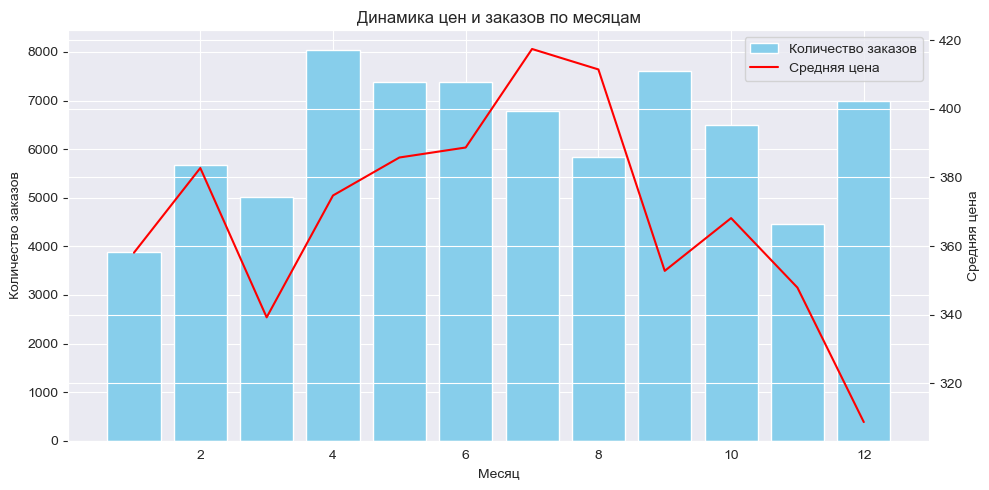

In [322]:
bombardilo_crocodilo = games_cln.groupby('month')['good_price'].mean() #средние цены по месяцам
lirili_larila = games_cln.groupby('month')['client_id'].count() #количество заказов по месяцам

fig, ax1 = plt.subplots(figsize=(10, 5))
bar = ax1.bar(lirili_larila.index, lirili_larila.values, color = 'skyblue', label = 'Количество заказов')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Количество заказов')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()  

line, = ax2.plot(bombardilo_crocodilo.index, bombardilo_crocodilo.values, color = 'red', label = 'Средняя цена')
ax2.set_ylabel('Средняя цена')
ax2.tick_params(axis='y')

plt.title('Динамика цен и заказов по месяцам')
plt.legend(handles=[bar, line], labels=['Количество заказов', 'Средняя цена'])
fig.tight_layout() 
plt.show()

Учитывая возможные искажения данных, связанные с неполным охватом временного периода (данные представлены с 01-01-2022
по 29-10-2023), сделаем выводы о наличии следующих тенденций:
* Рост цен весной и летом и снижение зимой и осенью 
* Рост заказов при росте цен в весенние месяцы 
* Снижение заказов при снижении цен в осенние месяцы 
* Высокие продажи в декабре при низких средних ценах 

**Цены по популярности игр**

In [323]:
games_unique = games_cln.drop_duplicates(subset=['good_name'], keep='first')
games_unique #датасет с уникальными названиями игр

,id,client_id,order_day,category_id,category_name,good_id,good_name,good_price,good_cnt,gender_cd,age,education_level,city_nm,monthly_income_amt,steam_popularity_score,grouped_category,month
0,1500571355,5-25R6ZT3L9,2023-05-22,29688,Скидки,890257,The Night of the Rabbit,299.00,1.0,M,28,UGR,Москва,73552,0.0,Другое,5
1,1500571245,5-2P4Z5VSMF,2023-05-22,28574,Ролевые (RPG),1436296,Ni no Kuni Wrath of the White Witch Remastered,269.85,1.0,M,26,GRD,Москва,281417,0.0,Ролевые (RPG),5
2,1500573164,5-YGO64ONA,2023-05-24,30659,Казуальные игры,1179848,KeyWe - The 100th Annual Grand Ol' Telepost To...,77.00,1.0,M,30,GRD,Москва,86000,0.0,Другое,5
4,1500288143,5-1QCUV9SY7,2022-07-03,28577,Экшн,1314503,Neon White,550.00,1.0,M,38,GRD,Санкт-Петербург,32000,1676.0,Экшн,7
5,1500272141,5-MDJBUKHR,2022-06-07,28565,Симуляторы,1123552,The Dweller,13.00,1.0,M,26,UGR,Москва,92000,0.0,Симуляторы,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88325,1500301106,5-356NAI3KQ,2022-07-24,28555,Стратегии,848464,Europa Universalis IV: Rights of Man Content P...,74.50,1.0,M,20,SCH,Самара,32000,0.0,Стратегии,7
88340,1500325503,5-22P21PJMI,2022-08-31,28577,Экшн,849007,Tom Clancy's Splinter Cell: Double Agent,104.75,1.0,M,41,UGR,Санкт-Петербург,32000,0.0,Экшн,8
88397,1500412462,5-NNU4XS5H,2022-12-10,28555,Стратегии,848167,Panzer Tactics HD,249.00,1.0,M,50,GRD,Санкт-Петербург,44000,0.0,Стратегии,12
88498,1500256517,1-CLKT3FQ,2022-05-11,28555,Стратегии,847660,Europa Universalis IV: Common Sense Content Pa...,74.50,1.0,M,36,GRD,Москва,290000,0.0,Стратегии,5


In [324]:
games_unique[games_unique['steam_popularity_score'] == 0].shape

(2441, 17)

2441 игра не может иметь первое место в рейтинге, поэтому, раз не сказано иного, будем интерпретировать позицию 0 как отсуствие игры в рейтинге.

Инвертируем рейтинг так, чтобы более высокие значения отражали большую популярность.

In [325]:
def calc_popularity(rank):
    if rank > 0:
        return 1/rank
    else:
        return 0

games_cln['popularity_score'] = games_cln['steam_popularity_score'].apply(calc_popularity) 
#чем больше popularity_score, тем популярнее игра

C:\Users\User\AppData\Local\Temp\ipykernel_23004\1753607726.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_cln['popularity_score'] = games_cln['steam_popularity_score'].apply(calc_popularity)


Коэффициент корреляции между играми, которые есть в рейтинге самых популярных, и их ценами: 0.21
Axes(0.125,0.11;0.775x0.77)


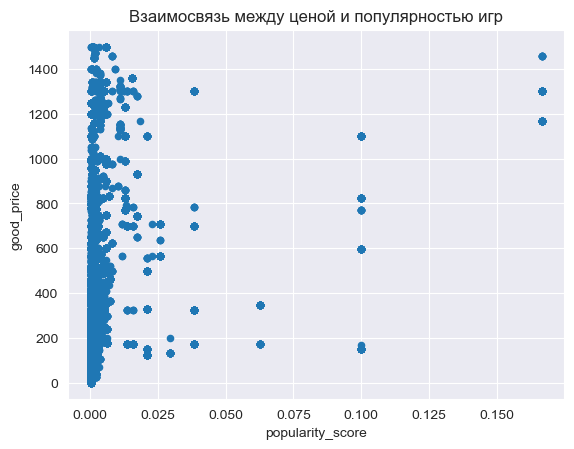

In [326]:
filtered_games = games_cln[games_cln['popularity_score'] > 0]
print(f'Коэффициент корреляции между играми, которые есть в рейтинге самых популярных, и их ценами: {round(filtered_games["popularity_score"].corr(filtered_games["good_price"]), 2)}')
print(filtered_games.plot.scatter(x='popularity_score', y='good_price', title = 'Взаимосвязь между ценой и популярностью игр'))

По графику рассеяния не видно взаимосвязи популярностью игр и их ценами. Несмотря на небольшое количество высокорейтинговых и дорогих игр, цена большинства игр не коррелирует с уровнем их популярности.

## **Оценка эластичности спроса**

Для расчета эластичности спроса по цене необходимы данные об изменении объёма спроса на игры в ответ на изменение их цен. Поскольку в представленном датафрейме такие данные отсутствуют, построим модель, оценивающую ценовую эластичность конкретной игры по ее признакам:
* ценовой диапазон
* доля спроса заядлых и остальных игроков
* наличие игры в категории Скидки

**Объяснение методики:**
* Предполагается, что игры низкого и среднего ценового диапазона, которые помимо других категорий также представлены в категории Скидки, обладают высокой ценовой эластичностью. Спрос на данные игры более чувствителен к изменению цены.
* Игры высокого ценового диапазона, которые не представлены в категории Скидки, обладают низкой ценовой эластичностью. Спрос на данные игры менее чувствителен к изменению цены.
* Заядлые игроки, которые в силу своей лояльности или зависимости готовы покупать игры даже при значительном изменении цен на них, формируют менее эластичный спрос на игры, чем остальные игроки.

**Определим долю покупок игр заядлыми игроками**

In [327]:
total_purchases = games_cln['good_name'].value_counts().rename('total_purchases')
compulsive_purchases = games_cln[games_cln['client_id'].isin(compulsive_gamers_df['client_id'])]['good_name'].value_counts().rename('compulsive_purchases')
merged_purchases = pd.merge(total_purchases, compulsive_purchases, left_index=True, right_index=True, how='outer')
merged_purchases.fillna(0, inplace=True)
merged_purchases['compulsive_demand_share'] = merged_purchases['compulsive_purchases'] / merged_purchases['total_purchases']
merged_purchases

,total_purchases,compulsive_purchases,compulsive_demand_share
good_name,,,
//N.P.P.D. RUSH// - The milk of Ultraviolet,5,2.0,0.400000
//SNOWFLAKE TATTOO//,3,2.0,0.666667
11-11 Memories Retold,13,8.0,0.615385
112 Operator,28,14.0,0.500000
15 Days,8,4.0,0.500000
...,...,...,...
looK INside - Chapter 1,10,5.0,0.500000
looK INside - Chapter 2,6,3.0,0.500000
looK INside - Chapter 2 Soundtrack - DLC,2,0.0,0.000000


Разделим игры на три категории:
* высокий спрос заядлых игроков (доля покупок игр этой категорией больше 3 квартиля)
* умеренный спрос заядлых игроков (доля покупок игр этой категорией больше 1 квартиля, но меньше 3 квартиля)
* низкий спрос заядлых игроков (доля покупок игр этой категорией меньше 1 квартиля)

In [328]:
q1_c = merged_purchases['compulsive_demand_share'].quantile(0.25)
q3_c = merged_purchases['compulsive_demand_share'].quantile(0.75)

def сompulsive_segmentation(share): 
    if share < q1_c:
        return 'Низкий'
    elif share < q3_c:
        return 'Средний'
    else:
        return 'Высокий'

merged_purchases['compulsive_demand'] = merged_purchases['compulsive_demand_share'].apply(сompulsive_segmentation)
merged_purchases

,total_purchases,compulsive_purchases,compulsive_demand_share,compulsive_demand
good_name,,,,
//N.P.P.D. RUSH// - The milk of Ultraviolet,5,2.0,0.400000,Средний
//SNOWFLAKE TATTOO//,3,2.0,0.666667,Средний
11-11 Memories Retold,13,8.0,0.615385,Средний
112 Operator,28,14.0,0.500000,Средний
15 Days,8,4.0,0.500000,Средний
...,...,...,...,...
looK INside - Chapter 1,10,5.0,0.500000,Средний
looK INside - Chapter 2,6,3.0,0.500000,Средний
looK INside - Chapter 2 Soundtrack - DLC,2,0.0,0.000000,Низкий


**Добавим признак id_discount, определяющий представлена ли игра в категории Скидки**

In [329]:
def is_in_discount(categories): 
    if 'Скидки' in categories:
        return 'да'
    else:
        return 'нет'

grouped_categories = games_cln.groupby('good_name')['category_name'].apply(list)
merged_purchases['is_discount'] = merged_purchases.index.map(lambda x: is_in_discount(grouped_categories.loc[x]) 
                                                             if x in grouped_categories.index else 'нет')
merged_purchases

,total_purchases,compulsive_purchases,compulsive_demand_share,compulsive_demand,is_discount
good_name,,,,,
//N.P.P.D. RUSH// - The milk of Ultraviolet,5,2.0,0.400000,Средний,да
//SNOWFLAKE TATTOO//,3,2.0,0.666667,Средний,нет
11-11 Memories Retold,13,8.0,0.615385,Средний,нет
112 Operator,28,14.0,0.500000,Средний,нет
15 Days,8,4.0,0.500000,Средний,да
...,...,...,...,...,...
looK INside - Chapter 1,10,5.0,0.500000,Средний,нет
looK INside - Chapter 2,6,3.0,0.500000,Средний,нет
looK INside - Chapter 2 Soundtrack - DLC,2,0.0,0.000000,Низкий,нет


**Добавим разделение игр по центовым сегментам**

Разделим игры на 3 ценовых сегмента:

* дешевые (цена ниже первого квартиля)
* средние (цена выше первого квартиля и ниже третьего крватиля)
* дорогие (цена выше третьего квартиля)

In [330]:
q1 = games_cln['good_price'].quantile(0.25)
q3 = games_cln['good_price'].quantile(0.75)

def price_segmentation(price): 
    if price < q1:
        return 'Дешевая'
    elif price < q3:
        return 'Средняя'
    else:
        return 'Дорогая'

games_cln['price_seg'] = games_cln['good_price'].apply(price_segmentation)

price_seg_map = games_cln.groupby('good_name')['price_seg'].first().to_dict()
merged_purchases['price_seg'] = merged_purchases.index.map(price_seg_map)
merged_purchases

C:\Users\User\AppData\Local\Temp\ipykernel_23004\3064236945.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_cln['price_seg'] = games_cln['good_price'].apply(price_segmentation)


,total_purchases,compulsive_purchases,compulsive_demand_share,compulsive_demand,is_discount,price_seg
good_name,,,,,,
//N.P.P.D. RUSH// - The milk of Ultraviolet,5,2.0,0.400000,Средний,да,Дешевая
//SNOWFLAKE TATTOO//,3,2.0,0.666667,Средний,нет,Дешевая
11-11 Memories Retold,13,8.0,0.615385,Средний,нет,Средняя
112 Operator,28,14.0,0.500000,Средний,нет,Дешевая
15 Days,8,4.0,0.500000,Средний,да,Дешевая
...,...,...,...,...,...,...
looK INside - Chapter 1,10,5.0,0.500000,Средний,нет,Дешевая
looK INside - Chapter 2,6,3.0,0.500000,Средний,нет,Средняя
looK INside - Chapter 2 Soundtrack - DLC,2,0.0,0.000000,Низкий,нет,Дешевая


**Функция для оценки эластичности спроса и выдвижения рекомендаций для конкретной игры**

In [331]:
def estimate_elasticity(good_name):
    if good_name not in merged_purchases.index:
        return 'Нет информации по данной игре'
    
    game_data = merged_purchases.loc[good_name]
    price_segment = game_data['price_seg']
    compulsive_demand = game_data['compulsive_demand']
    is_discounted = game_data['is_discount']

    if price_segment == 'Дешевая' and compulsive_demand == 'Низкий' and is_discounted == 'нет':
        return (
            """Очень высокая
            Рекомендация: Сохранить текущий уровень цен. Увеличивать выручку посредством стимулирования продаж за счет внедрения 
            специальных предложений и персонализированных акционных предложений.""")
        
    elif (price_segment == 
          'Дешевая' and compulsive_demand == 
          'Низкий' and is_discounted == 
          'да') or (price_segment == 
                    "Дешевая" and compulsive_demand
                    == 'Средний' and is_discounted == 'нет') or (price_segment == 
                                                                 "Средняя" and compulsive_demand == 'Низкий' and is_discounted == 'нет'):
        return (
            """Высокая
            Рекомендация: Сохранить текущий уровень цен. Увеличивать выручку посредством стимулирования продаж за счет 
            внедрения акционных предложений, а также посредством увеличения среднего чека (для этого можно внедрить в продажи 
            выгодные по цене и привлекательные по составу наборы игр).""")
        
    elif (price_segment == 
          'Дешевая' and compulsive_demand
          == 'Средний' and is_discounted == 'да') or (price_segment == 'Средняя' and compulsive_demand == 'Низкий' and is_discounted == 'да'):
        return (
            """Средне-высокая
            Рекомендация: Рассмотреть возможность частичного повышения цен на отдельные категории продуктов.
            Стимулировать продажи за счет сезонных скидок, программ лояльности и персонализированных предложений.""")
        
    elif (price_segment ==
          'Дешевая' and compulsive_demand 
          =='Высокий' and is_discounted == 'нет' or is_discounted ==
          'да') or (price_segment
                    == 'Средняя' and compulsive_demand ==
                                    'Средний' and is_discounted
                    == 'да' or is_discounted 
                    == 'нет') or (price_segment
                                  == 'Дорогая' and compulsive_demand 
                                  == 'Низкий' and is_discounted ==
                                  'нет') or (price_segment == 'Дорогая' and compulsive_demand == 'Средний' and is_discounted == 'да'):
        return (
            """Средняя
            Рекомендация: Удерживать стабильный ценовой сегмент. Периодически стимулировать продажи с помощью сезонных скидок.
            Обеспечивать оптимальное соотношение цены и качества продукции для привлечения и удержания клиентов.""")
        
    elif (price_segment == 
          'Средняя' and compulsive_demand == 
          'Высокий' and is_discounted == 
          'нет') or (price_segment ==
                     'Дорогая' and compulsive_demand == 
                     'Средний' and is_discounted == 'нет') or (price_segment 
                                                               == 'Дорогая' and compulsive_demand == 'Высокий' and is_discounted == 'да'):
        return (
            """Низкая
            Рекомендация: Не стремиться к увеличению объема продаж. Увеличивать выручку за счет премиальной ценовой политики. 
            Повышать лояльность аудитории за счет привлекательных подписок и персонализированных предложений.""")
        
    elif (price_segment 
          == 'Средняя' and compulsive_demand == 
          'Высокий' and is_discounted =='да') or (price_segment == 'Дорогая' and compulsive_demand == 'Низкий' and is_discounted == 'да'):
        return (
            """Средне-низкая',
            Рекомендация: Удерживать стабильный ценовой сегмент.\nУвеличивать выручку за счет предложения качественного товара
            по сбалансированной цене. Водить редкие акционные предложения для поддержания долгосрочного интереса аудитории к продукции.""")
        
    elif price_segment == 'Дорогая' and compulsive_demand == 'Высокий' and is_discounted == 'нет':
        return (
            """Очень низкая
            Рекомендация: Не стремиться к увеличению объема продаж.\nУвеличивать выручку за счет премиальной ценовой политики и формирования 
            уникального ценностного предложения (акцент на эксклюзивности).""")

**Тестируем, выбирая случайную игру**

In [332]:
import random

In [333]:
test_game = random.choice(merged_purchases.index)  
print(f"Анализируем игру: {test_game}")
game_data = merged_purchases.loc[test_game, ['compulsive_demand', 'is_discount', 'price_seg']]
renamed_data = {
    'compulsive_demand': 'Спрос заядлых игроков',
    'is_discount': 'Представлена ли в категории Скидки',
    'price_seg': 'Ценовая категория'}

print("\nПризнаки:")
for col, renamed_col in renamed_data.items():
    print(f"{renamed_col}: {game_data[col]}")
    
elasticity = estimate_elasticity(test_game)
print(f"\nВывод: Эластичность спроса — {elasticity}") 

Анализируем игру: Hitman: Blood Money

Признаки:
Спрос заядлых игроков: Средний
Представлена ли в категории Скидки: нет
Ценовая категория: Дешевая

Вывод: Эластичность спроса — Высокая
            Рекомендация: Сохранить текущий уровень цен. Увеличивать выручку посредством стимулирования продаж за счет 
            внедрения акционных предложений, а также посредством увеличения среднего чека (для этого можно внедрить в продажи 
            выгодные по цене и привлекательные по составу наборы игр).


**Ограничения модели**

* Статичность - модель не учитывает динамику эластичности и не предполагает изменения факторов, влияющих на ее оценку, с течением времени.
* Ограниченный набор факторов - модель не учитывает влияние на эластичность прочих факторов, например влияние конкурентной среды и сезонные колебания цен.
* Приближенные оценки - модель не дает точного значения эластичности спроса по цене в силу ограниченности имеющихся данных.
* Упрощенная методология - деление факторов, влияющих на эластичность, на категории не позволяет в полной мере учесть вариативность данных и может приводить к неточности классификации игр по уровню эластичности.